## Trabalho Computacional 3 - João Victor Silva Santos - 211045632

### Instalação de pacotes.

In [1]:
# Pacote para usar minha placa de vídeo (GTX 1650)
#%pip install torchaudio --index-url https://download.pytorch.org/whl/cu118

#%pip install pytorch-lightning

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import pytorch_lightning as pl
import torch.nn as nn
from torchmetrics.functional import accuracy
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer
import matplotlib.pyplot as plt
import numpy as np

### Preparação do dataset

In [2]:
class CIFAR10():  #@save    
    def __init__(self, root, resize=(224, 224)):    
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        self.train = torchvision.datasets.CIFAR10(
            root=root, train=True, transform=trans, download=True)
        train_set_size = int(len(self.train) * 0.8)
        valid_set_size = len(self.train) - train_set_size
        seed = torch.Generator().manual_seed(42)
        self.train, self.val = torch.utils.data.random_split(self.train, [train_set_size, valid_set_size], generator=seed)
        self.test = torchvision.datasets.CIFAR10(
            root=root, train=False, transform=trans, download=True)
        
dataset = CIFAR10(root="./data/")

train_dataloader = torch.utils.data.DataLoader(dataset.train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_dataloader = torch.utils.data.DataLoader(dataset.val, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_dataloader = torch.utils.data.DataLoader(dataset.test, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Number of training examples: {len(dataset.train)}")
print(f"Number of validation examples: {len(dataset.val)}")
print(f"Number of test examples: {len(dataset.test)}")

Files already downloaded and verified
Files already downloaded and verified
Number of training examples: 40000
Number of validation examples: 10000
Number of test examples: 10000


> Diferentemente dos trabalhos anteriores, o early-stoping requer que o dataset também tenha um conjunto de teste separado do de validação.

> Modifiquei alguns parâmetros nos dataloaders para que sejam carregados de forma mais eficiente para minha placa de vídeo. num_workes representa o núimero de cores do processador que prepararão os dados para que sejam enviados para a placa de vídeo para que ela fique responsável apenas pelas contas pesadas. pin_memory garante uma comunicação prioritária entre o processador e a placa de vídeo.

> Diminuí o tamanho do batch para evitar overflow de memória quando for treinar MLP ligada à VGG utilizando minha placa de vídeo.

Amostra do dataset CIFAR-10 (Redimensionado para 224x224):


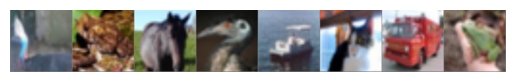

Rótulos:  bird | frog | horse | bird | ship | cat | truck | frog


In [3]:
# Definindo as classes do CIFAR-10
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# Função para desnormalizar e mostrar a imagem
def imshow(img):
    img = img / 2 + 0.5     # Desnormaliza de [-1, 1] para [0, 1]
    npimg = img.numpy()
    # O PyTorch usa o formato [C, H, W], o Matplotlib usa [H, W, C]
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Pega um batch de imagens de treino
dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# Mostra um grid com as 8 primeiras imagens do batch
print("Amostra do dataset CIFAR-10 (Redimensionado para 224x224):")
imshow(torchvision.utils.make_grid(images[:8]))
print('Rótulos: ', ' | '.join(f'{classes[labels[j]]}' for j in range(8)))

### Criação do modelo MLP

In [4]:
class LightModel(pl.LightningModule):
	def __init__(self,model,lr=1e-5):
		super().__init__()
		self.model = model
		self.lr = lr
	def training_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		loss = nn.functional.cross_entropy(y_hat, y)
		self.log("train_loss", loss)
		return loss
	def validation_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		loss = nn.functional.cross_entropy(y_hat, y)
		self.log("val_loss", loss)
		return loss
	def test_step(self, batch):
		X, y = batch
		y_hat = self.model(X)
		preds = torch.argmax(y_hat, dim=1)
		acc = accuracy(preds, y, task="multiclass", num_classes=10)
		self.log("test_acc", acc)
		loss = nn.functional.cross_entropy(y_hat, y)		
		self.log("test_loss", loss)		
	def configure_optimizers(self):
		optimizer = torch.optim.Adam(self.parameters(), self.lr)
		return optimizer


arch = nn.Sequential(
			nn.Flatten(),
			nn.Linear(3*224*224,512),
			nn.ReLU(),
			nn.Linear(512,128),
			nn.ReLU(),
			nn.Linear(128,10)	
	)

mlp = LightModel(arch)

> Escolhi os valores 512 e 128 para tentar balancear complexidade da rede e tempo de treinamento.

### Treinamento e métricas do modelo MLP

In [5]:
print("CUDA disponível:", torch.cuda.is_available())

CUDA disponível: True


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    min_delta=0.001
)

trainer = Trainer(callbacks=[early_stopping], max_epochs=50, accelerator="gpu")

In [ ]:
trainer.fit(model=mlp, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

In [18]:
trainer.save_checkpoint("mlp.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


In [12]:
modelo_carregado = LightModel.load_from_checkpoint("mlp.ckpt", model=arch)

modelo_carregado.eval()

modelo_carregado.cuda()

print("Modelo carregado!")

Modelo carregado!


In [14]:
trainer.test(model=modelo_carregado, dataloaders=test_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5322999954223633
        test_loss           1.3663415908813477
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_acc': 0.5322999954223633, 'test_loss': 1.3663415908813477}]

> Mesmo com o early stopping para previnir o sobre ajuste e com um número grande de neurônios nas camadas densas, o modelo não apresentou um desempenho satisfatório.

In [15]:
arch2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*224*224, 512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(128, 10)
)

mlp2 = LightModel(arch2)

In [ ]:
trainer2 = Trainer(callbacks=[early_stopping], max_epochs=50, accelerator="gpu")

In [ ]:
trainer2.fit(model=mlp2, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

In [18]:
trainer2.save_checkpoint("mlp2.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


In [22]:
modelo_carregado2 = LightModel.load_from_checkpoint("mlp2.ckpt", model=arch2)

modelo_carregado2.eval()

modelo_carregado2.cuda()

print("Modelo carregado!")

Modelo carregado!


In [23]:
trainer.test(model=modelo_carregado2, dataloaders=test_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5333999991416931
        test_loss           1.3520396947860718
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_acc': 0.5333999991416931, 'test_loss': 1.3520396947860718}]

> Mesmo utilizando técnicas como dropout para tentar melhorar a capacidade de generalização da rede, o desempenho não foi satisfatório. Assim como previsto no enunciado. Isso mostra a limitação das MLPs nas tarefas de classificação, pois para atingir um resultado melhor o modelo exigiria uma maior complexidade, e ainda assim, isso não necessariamente traria um desempenho satisfatório, e com certeza acarretaria num tempo de treinamento elevado.

### Criação do modelo usando VGG16

In [26]:
from torchvision.models import vgg16
vgg16_model = vgg16(weights="DEFAULT", progress=True)

for param in vgg16_model.parameters():
	param.requires_grad = False

print(vgg16_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [27]:
# Modificando o bloco de classificação da VGG16
vgg16_model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(25088, 50),
    nn.ReLU(),
    nn.Linear(50, 20),
    nn.ReLU(),
    nn.Linear(20, 10)
)

# Visualizando a arquitetura modificada
print(vgg16_model.classifier)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=25088, out_features=50, bias=True)
  (2): ReLU()
  (3): Linear(in_features=50, out_features=20, bias=True)
  (4): ReLU()
  (5): Linear(in_features=20, out_features=10, bias=True)
)


> É possível notar que o classifier proposto possui uma arquitetura mais simples que o classifier original, sem as camadas de dropout, e possui menor complexidade. Também é possível observar que este possui complexidade menor que a MLP da primeira parte deste trabalho.

### Treinamento e métricas do modelo VGG16 pré-treinado

In [28]:
vgg_light_model = LightModel(vgg16_model)

In [29]:
early_stopping_vgg = EarlyStopping(
    monitor='val_loss', 
    patience=5,          
    mode='min',          
    min_delta=0.001      
)

In [ ]:
trainer_vgg = Trainer(
    callbacks=[early_stopping_vgg], 
    max_epochs=50,
    accelerator="gpu",
    devices=1
)

In [ ]:
trainer_vgg.fit(
    model=vgg_light_model, 
    train_dataloaders=train_dataloader, 
    val_dataloaders=val_dataloader
)

In [25]:
trainer_vgg.save_checkpoint("vgg.ckpt")
print("Modelo salvo com sucesso no disco!")

`weights_only` was not set, defaulting to `False`.


Modelo salvo com sucesso no disco!


In [31]:
modelo_carregado_vgg = LightModel.load_from_checkpoint("vgg.ckpt", model=vgg16_model)

modelo_carregado_vgg.eval()

modelo_carregado_vgg.cuda()

print("Modelo carregado!")

Modelo carregado!


In [32]:
trainer.test(model=modelo_carregado_vgg, dataloaders=test_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.858299970626831
        test_loss           0.42138463258743286
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_acc': 0.858299970626831, 'test_loss': 0.42138463258743286}]

>Ao contrário do modelo puramente composto pela MLP, o modelo baseado na rede convolucional pré-treinada VGG16 apresentou um desempenho relativo muito melhor. Isso se dá pelo fato das redes convolucionais serem mais adequadas para as tarefas de classificação de imagens. E mesmo se tratando de uma rede pré-treinada e com os parâmetros congelados, por ser uma rede profunda, foram necessárias várias horas para treiná-la.

> O ponto interessante é que o classifier proposto tem uma arquitetura muito menos complexa que a MLP da primeira parte do trabalho e ainda assim conseguimos um resultado bem melhor. Isso evidencia a influência das camadas convolucionais na tarefa de classificação e sua superioridade nesse tipo de tarefa em comparação à MLPs puras.